In [1]:
import sympy as sym
from sympy.printing.dot import dotprint
import graphviz

In [2]:
def sympy_expr_to_graph(expr,fillcolor='lightblue'):
    """
    Convert a SymPy expression into a Graphviz Digraph for visualization.
    """
    #dot = graphviz.Digraph(comment="SymPy Expression Tree")
    dot = graphviz.Digraph(
        comment="SymPy Expression Tree",
        graph_attr={'bgcolor': 'transparent'},
        node_attr={'style': 'filled', 'fillcolor': fillcolor},
    )    
    visited = {}

    def add_node(e):
        # Use id(e) to uniquely identify nodes
        node_id = str(id(e))
        if node_id not in visited:
            visited[node_id] = True
            # Label: operator or symbol/number
            etype = type(e)
            etype_name = str(etype).split('.')[-1].split("'")[0]  #strip off only the fundamental not the whole class hierarchy
            label = str(e)
            new_label = etype_name+'\n'+label
            #print(new_label)
            dot.node(node_id, new_label)

            # Recursively add children
            if hasattr(e, 'args'):
                for arg in e.args:
                    child_id = add_node(arg)
                    dot.edge(node_id, child_id)
        return node_id

    add_node(expr)
    return dot


def graph_expr(expr,color='white'):
    styles = [(Basic, {'style': 'filled',
                       'fillcolor': color,
                       'shape': 'ellipse'})]
    dot_form = dotprint(expr, styles=styles)
    return graphviz.Source(dot_form)

def export_expression(expr,dpi_num,filename_no_suffix,file_format,fillcolor='White'):
    temp = setg(expr,fillcolor=fillcolor)
    temp.attr(dpi=str(dpi_num))
    temp.render(filename_no_suffix,format='png', cleanup=True)

In [68]:
a,b,c,x,y = sym.symbols('a:c x:y')

# Master Expression

In [70]:
Q = a + x + 2*x**2 + 3*x**3 + 4*x**4 + 5*sym.cos(x) + 6*sym.cos(x**2) + 7*sym.cos(x)**2 + 8*sym.cos(b) + 9*sym.exp(-x**2)
display(Q)

a + 4*x**4 + 3*x**3 + 2*x**2 + x + 8*cos(b) + 7*cos(x)**2 + 5*cos(x) + 6*cos(x**2) + 9*exp(-x**2)

# Rule 1 $x^2 \rightarrow y$

In [72]:
Q.xreplace({x**2:y})

a + 4*x**4 + 3*x**3 + x + 2*y + 8*cos(b) + 7*cos(x)**2 + 5*cos(x) + 6*cos(y) + 9*exp(-y)

In [78]:
Q.subs({x**2:y})

a + 3*x**3 + x + 4*y**2 + 2*y + 8*cos(b) + 7*cos(x)**2 + 5*cos(x) + 6*cos(y) + 9*exp(-y)

In [79]:
Q.replace(x**2,y)

a + 4*x**4 + 3*x**3 + x + 2*y + 8*cos(b) + 7*cos(x)**2 + 5*cos(x) + 6*cos(y) + 9*exp(-y)

## Rule 2 $\cos(x) \rightarrow \sin(x)$

In [80]:
Q.xreplace({sym.cos(x):sym.sin(x)})

a + 4*x**4 + 3*x**3 + 2*x**2 + x + 7*sin(x)**2 + 5*sin(x) + 8*cos(b) + 6*cos(x**2) + 9*exp(-x**2)

In [81]:
Q.subs({sym.cos(x):sym.sin(x)})

a + 4*x**4 + 3*x**3 + 2*x**2 + x + 7*sin(x)**2 + 5*sin(x) + 8*cos(b) + 6*cos(x**2) + 9*exp(-x**2)

In [82]:
Q.replace(sym.cos(x),sym.sin(x))

a + 4*x**4 + 3*x**3 + 2*x**2 + x + 7*sin(x)**2 + 5*sin(x) + 8*cos(b) + 6*cos(x**2) + 9*exp(-x**2)

In [83]:
w = sym.Wild('w')

In [84]:
Q.replace(sym.cos(w),sym.sin(w))

a + 4*x**4 + 3*x**3 + 2*x**2 + x + 8*sin(b) + 7*sin(x)**2 + 5*sin(x) + 6*sin(x**2) + 9*exp(-x**2)

# Images

##  Rule 1 - .xreplace

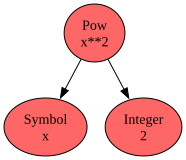

In [87]:
display(setg(x**2,fillcolor='#ff6666'))
export_expression(x**2,300,'A2D_06(Jun)_2026_Rule1_xreplace_fig1a','png',fillcolor='#ff6666')

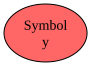

In [88]:
display(setg(y,fillcolor='#ff6666'))
export_expression(y,300,'A2D_06(Jun)_2026_Rule1_xreplace_fig1b','png',fillcolor='#ff6666')

# Final Thoughts

In [92]:
g = sym.Function('g')

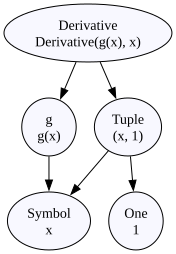

In [94]:
dexpr = sym.diff(g(x),x)
display(setg(dexpr,fillcolor='GhostWhite'))

In [103]:
new_expr = dexpr.replace(
    lambda e: isinstance(e, sym.Derivative),
    lambda e: sym.Mul(e.expr, *[v for v, _ in e.variable_count])
)
display(new_expr)

x*g(x)

# Case 1 - Variations of 'subs'

sqrt(y**2 + (-a + x)**2)

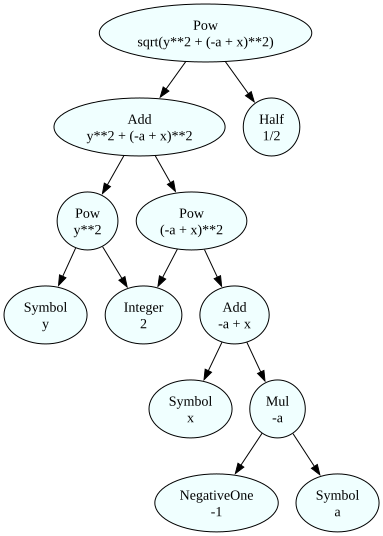

In [89]:
expr = sym.sqrt( (x-a)**2 + y**2 )
display(expr)
setg(expr,fillcolor="Azure")

sqrt(b**2 + y**2)

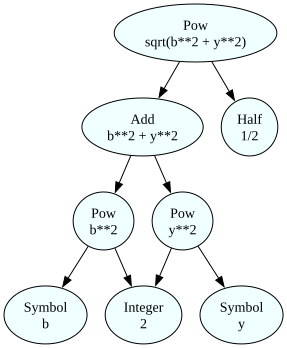

In [90]:
temp = expr.subs( (x-a)**2, b**2 )
display(temp)
setg(temp,fillcolor="Azure")

sqrt(y**2 + (-a + x)**2)

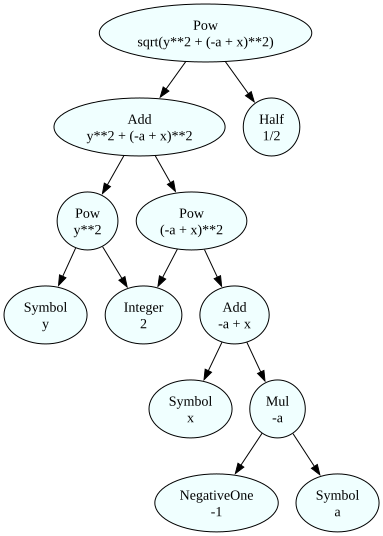

In [91]:
temp = expr.subs((a-x)**2,b**2)
display(temp)
setg(temp,fillcolor="Azure")

In [8]:
expr1 = sym.sqrt(a**2 + 2*a*x + x**2 + y**2) #+ sym.cos(x) + sym.exp(-b*y)
display(expr1)

sqrt(a**2 + 2*a*x + x**2 + y**2)

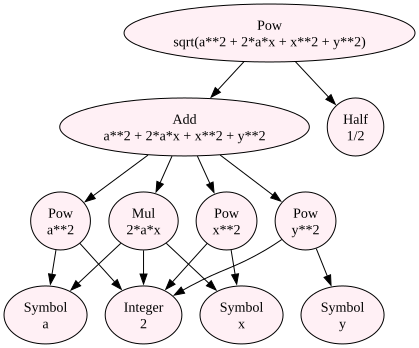

In [9]:
setg = sympy_expr_to_graph
setg(expr1,fillcolor='LavenderBlush')

sqrt(a**2 + 2*a*x + b + y**2)

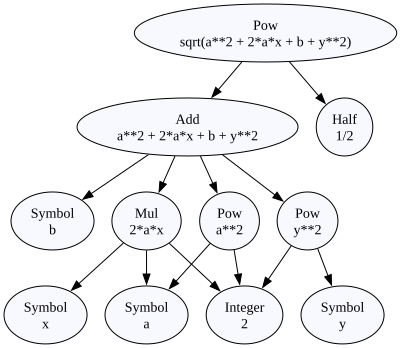

In [10]:
temp = expr1.subs(x**2,b)
display(temp)
setg(temp,fillcolor="GhostWhite")

sqrt(2*a*x + c + y**2)

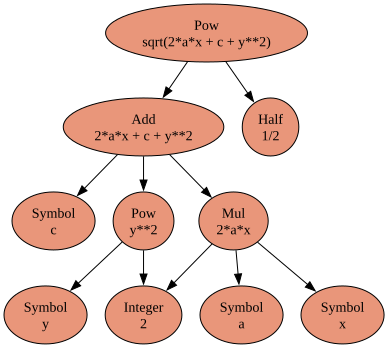

In [11]:
temp = expr1.subs(a**2 + x**2,c)
display(temp)
setg(temp,fillcolor="DarkSalmon")

sqrt(c + y**2)

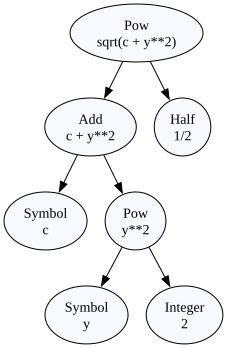

In [12]:
temp = expr1.subs(a**2 + 2*a*x + x**2,c)
display(temp)
setg(temp,fillcolor="GhostWhite")

sqrt(2*a*x + y**2 + 4/5)

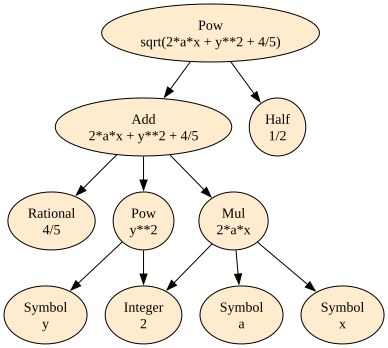

In [13]:
temp = expr1.subs(x**2 + a**2,sym.Rational(4,5))
display(temp)
setg(temp,fillcolor="BlanchedAlmond")

7/4

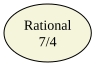

In [14]:
temp = expr1.subs(sym.sqrt(x**2 + 2*a*x + a**2 + y**2),sym.Rational(7,4))
display(temp)
setg(temp,fillcolor="Beige")

# Case2 - Variations of 'xreplace'

In [18]:
expr2 = x**2 + sym.cos(x)
display(expr2)

x**2 + cos(x)

In [31]:
expr2.xreplace({sym.cos(x):sym.sin(x)})

x**2 + sin(x)

In [56]:
expr2.replace(sym.cos(x),sym.sin(x))

x**2 + sin(x)

In [54]:
for term in expr3.args:
    display(term)

a

x

y

1/(x**2 + y**2)

a + 4*x**4 + 3*x**3 + 2*x**2 + x + 8*cos(b) + 7*cos(x)**2 + 5*cos(x) + 11*cos(x**2) + 9*exp(-x**2)

In [63]:
master_expr.subs(x**2,y)

a + 3*x**3 + x + 4*y**2 + 2*y + 8*cos(b) + 7*cos(x)**2 + 5*cos(x) + 11*cos(y) + 9*exp(-y)